In [25]:
import pandas as pd

df = pd.read_csv("taxi_sample.csv")
df

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1399190091620000213,B,NaN,10.0,20000213,1399190091,A,False,"[[-8.607096,41.150286],[-8.607123,41.150214],[..."
1,1398928351620000092,C,NaN,NaN,20000092,1398928351,A,False,"[[-8.638533,41.159133],[-8.63856,41.15907],[-8..."
2,1383056851620000263,B,NaN,9.0,20000263,1383056851,A,False,"[[-8.60652,41.144562],[-8.606934,41.144724],[-..."
3,1399758505620000503,B,NaN,13.0,20000503,1399758505,A,False,"[[-8.628246,41.157333],[-8.627733,41.157657],[..."
4,1390920415620000174,B,NaN,10.0,20000174,1390920415,A,False,"[[-8.607123,41.150331],[-8.607114,41.150295],[..."
...,...,...,...,...,...,...,...,...,...
85529,1400616422620000665,C,NaN,NaN,20000665,1400616422,A,False,"[[-8.612748,41.140413],[-8.612766,41.140413],[..."
85530,1392213120620000521,C,NaN,NaN,20000521,1392213120,A,False,"[[-8.632323,41.164479],[-8.632395,41.164326],[..."
85531,1385463326620000499,B,NaN,50.0,20000499,1385463326,A,False,"[[-8.628759,41.169789],[-8.628651,41.169798],[..."
85532,1380912162620000675,B,NaN,60.0,20000675,1380912162,A,False,"[[-8.609652,41.151231],[-8.609616,41.151267],[..."


Le but est de trouver les apoints de prise en charge des taxis. Pour cela on va prendre le points de départs de chaque trajet qui est le point de prise en charge. Avant de faire celà, éliminons les trajets non valide, c'est-à-dire les trajets qui n'ont aucune données GPS.

In [26]:
df_corrected = df.query("`POLYLINE` != '[]'")
df_corrected

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1399190091620000213,B,NaN,10.0,20000213,1399190091,A,False,"[[-8.607096,41.150286],[-8.607123,41.150214],[..."
1,1398928351620000092,C,NaN,NaN,20000092,1398928351,A,False,"[[-8.638533,41.159133],[-8.63856,41.15907],[-8..."
2,1383056851620000263,B,NaN,9.0,20000263,1383056851,A,False,"[[-8.60652,41.144562],[-8.606934,41.144724],[-..."
3,1399758505620000503,B,NaN,13.0,20000503,1399758505,A,False,"[[-8.628246,41.157333],[-8.627733,41.157657],[..."
4,1390920415620000174,B,NaN,10.0,20000174,1390920415,A,False,"[[-8.607123,41.150331],[-8.607114,41.150295],[..."
...,...,...,...,...,...,...,...,...,...
85529,1400616422620000665,C,NaN,NaN,20000665,1400616422,A,False,"[[-8.612748,41.140413],[-8.612766,41.140413],[..."
85530,1392213120620000521,C,NaN,NaN,20000521,1392213120,A,False,"[[-8.632323,41.164479],[-8.632395,41.164326],[..."
85531,1385463326620000499,B,NaN,50.0,20000499,1385463326,A,False,"[[-8.628759,41.169789],[-8.628651,41.169798],[..."
85532,1380912162620000675,B,NaN,60.0,20000675,1380912162,A,False,"[[-8.609652,41.151231],[-8.609616,41.151267],[..."


Maintenant que le dataset à été néttoyé, on va récupérer les coordonnée.

In [27]:
import numpy as np

x = df_corrected["POLYLINE"].str.findall(r"-?\d+[.,]\d+").apply(lambda x: float(x[0]))
y = df_corrected["POLYLINE"].str.findall(r"-?\d+[.,]\d+").apply(lambda x: float(x[1]))

df_coord = pd.DataFrame({"x": x, "y": y})
df_coord

,x,y
0,-8.607096,41.150286
1,-8.638533,41.159133
2,-8.606520,41.144562
3,-8.628246,41.157333
4,-8.607123,41.150331
...,...,...
85529,-8.612748,41.140413
85530,-8.632323,41.164479
85531,-8.628759,41.169789
85532,-8.609652,41.151231


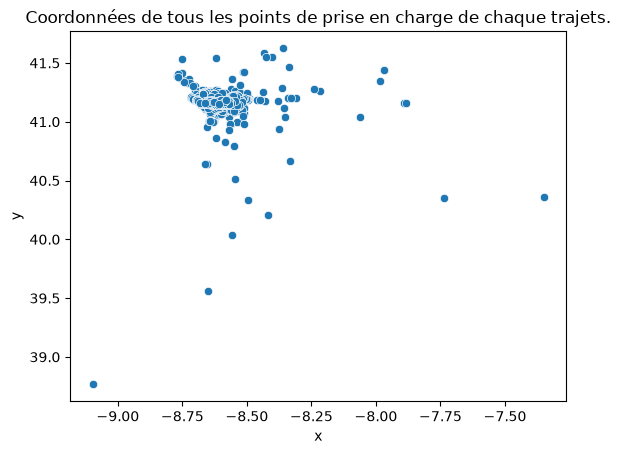

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(df_coord, x="x", y="y")
plt.title("Coordonnées de tous les points de prise en charge de chaque trajets.")
plt.show()

On voit un cluster principale avec quelque point qui s'éloigne. Le but de notre projet n'est pas de faire un clustering parfait mais c'est de trouver les hotspots locaux. Par conséquent on n'utiliseras pas le score de silhouette et on utiliseras 100 métres soit environ 0.001 des coordonnées GPS pour l'epsilon pour obtenir des hotspots réaliste au niveau de la distances réelle et pour le min_samples on va considérer qu'un points est un hotspots uniquement si il y a au moins 30 voisins.

In [29]:
from sklearn.cluster import DBSCAN

cluster = DBSCAN(eps=0.001, min_samples=30).fit_predict(df_coord)

In [30]:
df_coord["cluster"] = cluster

In [31]:
df_coord["cluster"].value_counts().sort_values(ascending=False)

cluster
 0     47148
-1      6615
 2      4869
 1      4615
 7      3018
       ...  
 87       30
 81       20
 86       19
 83       18
 84       11
Name: count, Length: 89, dtype: int64

On va maintenant créer un code qui prend les n plus grands hotspots et calcule la moyenne selon x et y pour trouver les coocrdonnées centrale de chaque hotspots.

In [32]:
df_finale = df_coord.query("`cluster` != -1")

In [33]:
def findHotspots(df, n):
    index_hotspots = (
        df["cluster"].value_counts().sort_values(ascending=False).index[0:n]
    )
    hotspots_coordinate = []
    for i in index_hotspots:
        data = df.query(f"`cluster` == {i}")
        mean_x = data["x"].mean()
        mean_y = data["y"].mean()
        hotspots_coordinate.append((mean_x, mean_y))
    return hotspots_coordinate


findHotspots(df_finale, 3)

[(np.float64(-8.613710801476202), np.float64(41.15157594597862)),
 (np.float64(-8.585716526802218), np.float64(41.14857615711645)),
 (np.float64(-8.64449421971831), np.float64(41.15668929230769))]

Les trois points se situe effectivement tous au centre de porto. Voilà la carte. Le pooints au milieu est le hotspots le plus grand, le points à droite est le deuxiéme et celui à gauche le troisiéme. Les trois points se situe tous dans une zone trés fréquenté. Donc notre code donne des résultats logiques.
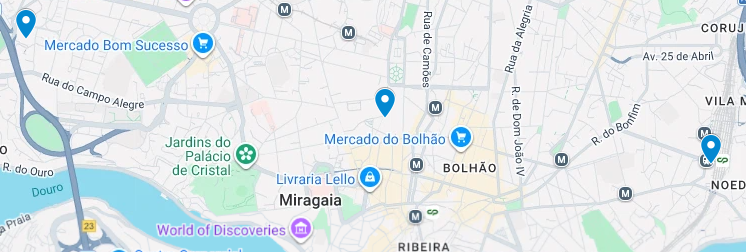 